## SENTIMENT ANALYSIS

## Hypotheses

### Axis 1: Sentiment classifier

#### VADER vs TextBlob

In [10]:
# Import the necessary modules 
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd 
import sys
import os 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# This 'goes up' two levels from your current subfolder to reach the project root
root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

if root_path not in sys.path:
    sys.path.insert(0, root_path)

# Verify 'src' is now visible
print(f"Project Root: {root_path}")
print(f"Is 'src' folder accessible? {os.path.exists(os.path.join(root_path, 'src'))}")
print(f"Is 'data' folder accessible? {os.path.exists(os.path.join(root_path, 'data'))}")

Project Root: D:\MSc Data Science\TB 2\IATA\CW\EMATM0067_2025_TB-2-g43
Is 'src' folder accessible? True
Is 'data' folder accessible? True


In [4]:
# Define the data directory relative to the root
data_dir = os.path.join(root_path, 'data', 'processed')
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_name = 'customer_support_tickets.csv' 
file_path = os.path.join(source_data_dir, file_name)

# load the dataframe
df = pd.read_csv(file_path)
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [8]:
vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['Ticket Description'].apply(lambda x: vader.polarity_scores(x)['compound'])
df['vader_label'] = df['vader_compound'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))
df['tb_polarity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['tb_subjectivity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['tb_label'] = df['tb_polarity'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

print("=== Sentiment Distribution ===")
print("\nVADER:")
print(df['vader_label'].value_counts())
print("\nTextBlob:")
print(df['tb_label'].value_counts())


=== Sentiment Distribution ===

VADER:
vader_label
Positive    6000
Negative    2109
Neutral      360
Name: count, dtype: int64

TextBlob:
tb_label
Positive    3766
Neutral     2794
Negative    1909
Name: count, dtype: int64


C:\Users\Thiruvel A P\AppData\Local\Temp\ipykernel_6512\241664362.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ticket Type', y='vader_compound', ax=axes[1,0], palette='viridis')
C:\Users\Thiruvel A P\AppData\Local\Temp\ipykernel_6512\241664362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ticket Type', y='tb_polarity', ax=axes[1,1], palette='viridis')


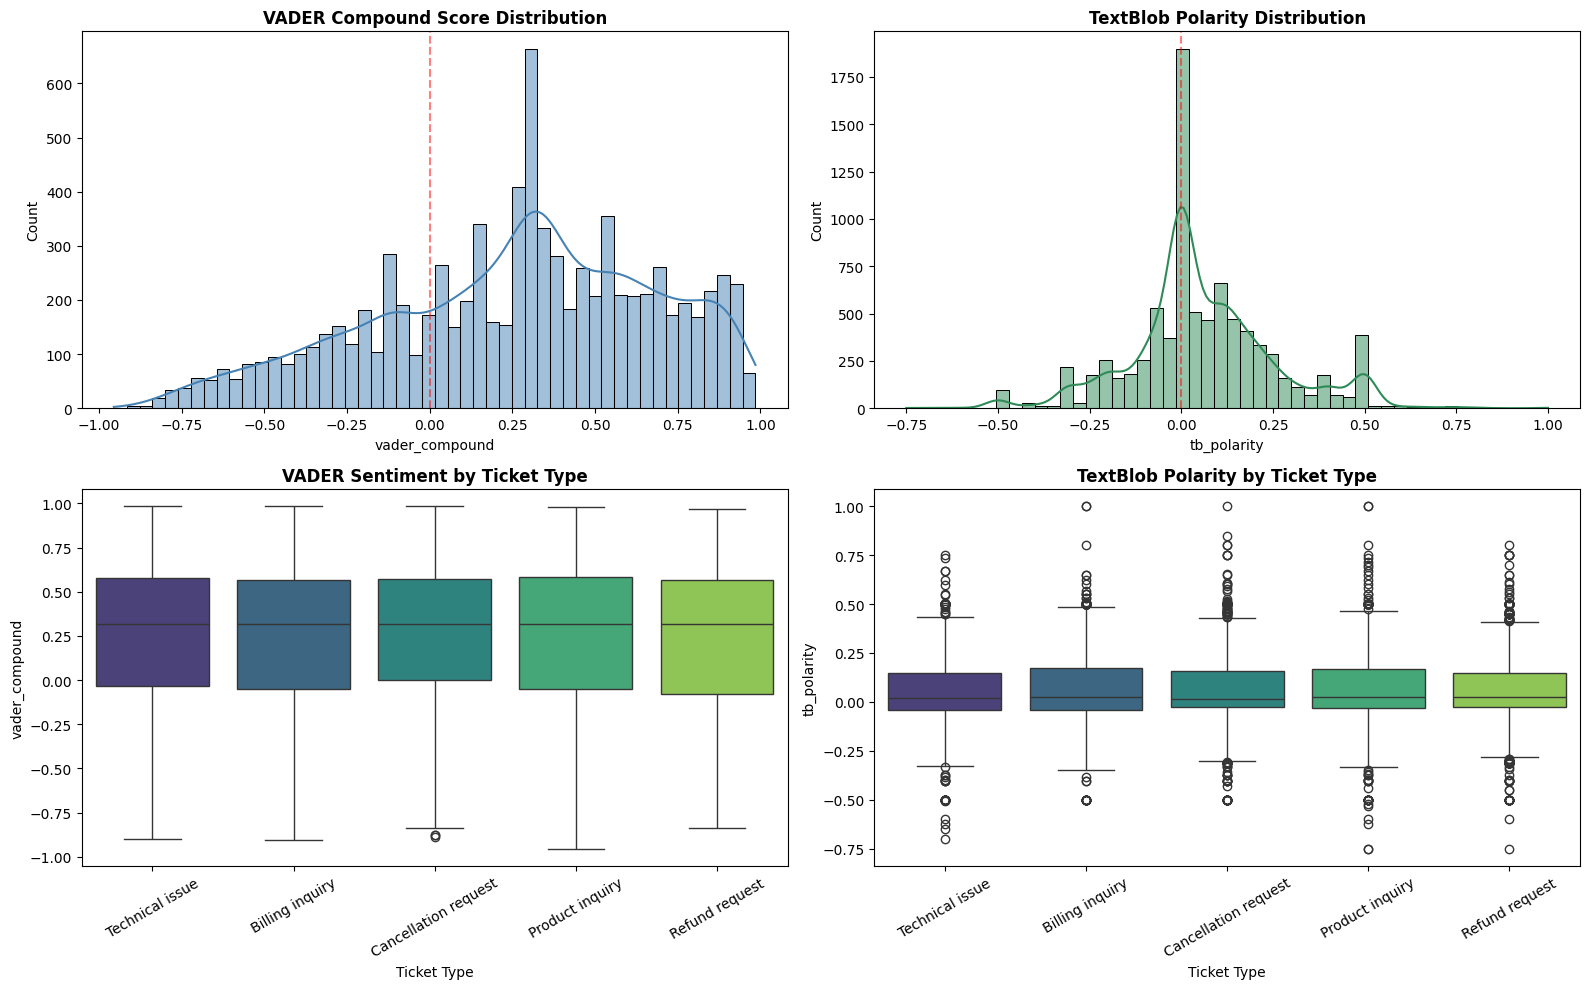

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df['vader_compound'], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0,0].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.histplot(df['tb_polarity'], bins=50, kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('TextBlob Polarity Distribution', fontweight='bold')
axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.boxplot(data=df, x='Ticket Type', y='vader_compound', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('VADER Sentiment by Ticket Type', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='Ticket Type', y='tb_polarity', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('TextBlob Polarity by Ticket Type', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

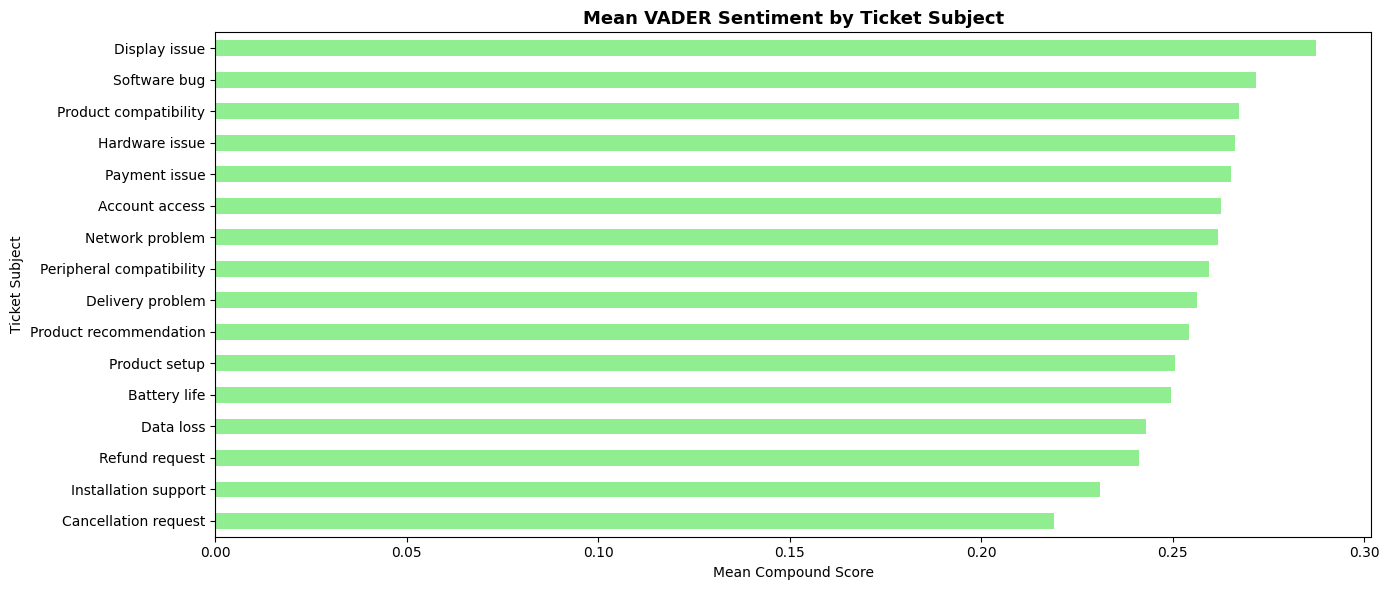

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
subject_sentiment = df.groupby('Ticket Subject')['vader_compound'].mean().sort_values()
subject_sentiment.plot(kind='barh', ax=ax, color=[
    'salmon' if v < -0.05 else ('lightgreen' if v > 0.05 else 'lightgray')
    for v in subject_sentiment.values])
ax.set_title('Mean VADER Sentiment by Ticket Subject', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Compound Score')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()